# Simple linear regression

X mean = 5.0
Y mean = 5.555555555555555
Regression coefficient (b1) = 0.6666666666666666
Intercept (b0) = 2.2222222222222223
Predicted values = [2.88888889 3.55555556 4.22222222 4.88888889 5.55555556 6.22222222
 6.88888889 7.55555556 8.22222222]


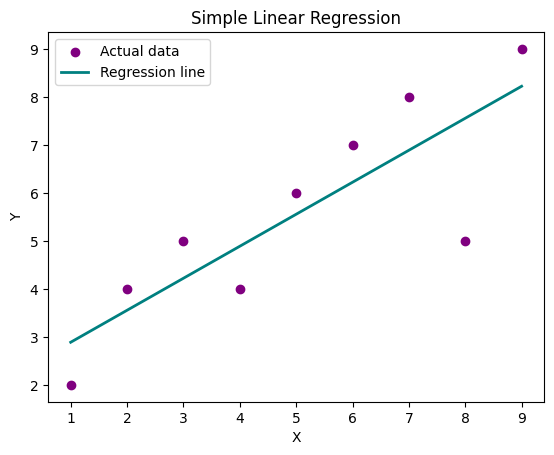

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
x = np.array([1,2,3,4,5,6,7,8,9]).reshape(-1, 1)
y = np.array([2,4,5,4,6,7,8,5,9])
x_mean = np.mean(x)
y_mean = np.mean(y)
print("X mean =", x_mean)
print("Y mean =", y_mean)
x_flat = x.flatten()
b1 = np.sum((x_flat - x_mean) * (y - y_mean)) / \
     np.sum((x_flat - x_mean) ** 2)
b0 = y_mean - b1 * x_mean
print("Regression coefficient (b1) =", b1)
print("Intercept (b0) =", b0)
model = LinearRegression()
model.fit(x, y)
x_line = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
y_line = model.predict(x_line)
print("Predicted values =", model.predict(x))
plt.scatter(x_flat, y, color="Purple", label="Actual data")
plt.plot(x_line, y_line, color="Teal", linewidth=2, label="Regression line")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()

# Sigmoid Activation 

Trained weights: [0.64846158 0.58387281]
Trained bias: -5.857652727253998
Final cost: 0.06512698704200094


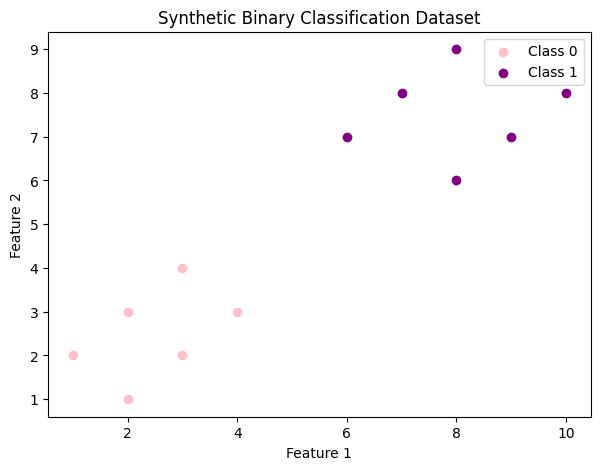

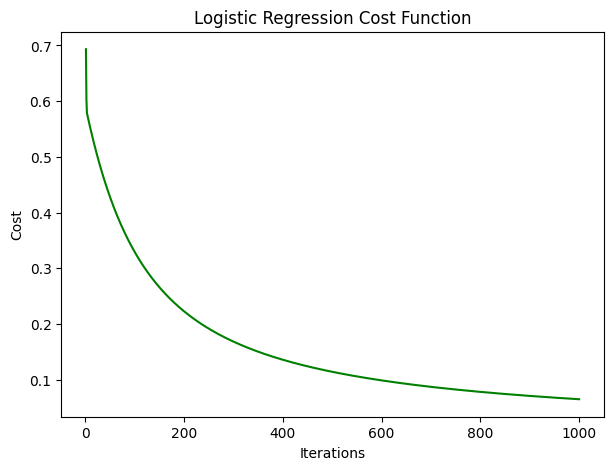

In [39]:
import numpy as np
import matplotlib.pyplot as plt
def sigmoid(z):
    return 1 / (1 + np.exp(-z)) #sigmoid fuction
X = np.array([[1, 2], [2, 3],[2, 1], [3, 2],[3, 4],[4, 3],
              [6, 7], [7, 8], [8, 6], [8, 9], [9, 7], [10, 8]])
y = np.array([ 0, 0, 0, 0, 0, 0,
              1, 1, 1, 1, 1, 1])
m, n = X.shape
weights = np.zeros(n)
bias = 0
learning_rate = 0.1
iterations = 1000
cost_history = []
for i in range(iterations):
    z = np.dot(X, weights) + bias
    predictions = sigmoid(z)
    epsilon = 1e-15
    predictions = np.clip(predictions, epsilon, 1 - epsilon)
    cost = -(1 / m) * np.sum(
        y * np.log(predictions) +
        (1 - y) * np.log(1 - predictions)
    )
    cost_history.append(cost)
    dw = (1 / m) * np.dot(X.T, (predictions - y))
    db = (1 / m) * np.sum(predictions - y)  #log loss
    weights -= learning_rate * dw
    bias -= learning_rate * db
print("Trained weights:", weights)
print("Trained bias:", bias)
print("Final cost:", cost_history[-1])
plt.figure(figsize=(7, 5))
plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    color="pink",
    label="Class 0"
)
plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    color="purple",
    label="Class 1"
)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Synthetic Binary Classification Dataset")
plt.legend()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(
    range(1, iterations + 1),
    cost_history,
    color="Green"
)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Logistic Regression Cost Function")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
iris = load_iris()
X = iris.data[:, :2]
#K = 2
kmeans2 = KMeans(n_clusters=2, random_state=42, n_init=10)
y_kmeans2 = kmeans2.fit_predict(X)
print("Results for K = 2")
print("Cluster Centers:")
print(kmeans2.cluster_centers_)
print("Inertia:", kmeans2.inertia_)
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans2, cmap='viridis', s=50)

plt.scatter(
    kmeans2.cluster_centers_[:, 0],
    kmeans2.cluster_centers_[:, 1],
    c='red',
    marker='X',
    s=200,
    label='Centroids'
)
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("K-Means Clustering of Iris Dataset (K = 2)")
plt.legend()
plt.show()
# K = 3
kmeans3 = KMeans(n_clusters=3, random_state=42, n_init=10)
y_kmeans3 = kmeans3.fit_predict(X)
print("\nResults for K = 3")
print("Cluster Centers:")
print(kmeans3.cluster_centers_)
print("Inertia:", kmeans3.inertia_)
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans3, cmap='viridis', s=50)

plt.scatter(
    kmeans3.cluster_centers_[:, 0],
    kmeans3.cluster_centers_[:, 1],
    c='red',
    marker='X',
    s=200,
    label='Centroids'
)
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("K-Means Clustering of Iris Dataset (K = 3)")
plt.legend()
plt.show()





# Naive Bayes Classification on Iris Dataset
# Using StandardScaler

import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
iris = load_iris()
X = iris.data
y = iris.target
print("Features:")
print(iris.feature_names)
print("\nTarget Names:")
print(iris.target_names)
print("\nDataset Shape:", X.shape)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)
scaler = StandardScaler() #featur scaling
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("\nScaled Training Data:")
print(X_train_scaled[:5])
# Apply Naive Bayes
model = GaussianNB()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
print("\nPredicted Values:")
print(y_pred)
print("\nActual Values:")
print(y_test)
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))
